In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from collections import Counter
from wordcloud import WordCloud

In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
df = pd.read_csv("Hotel_Reviews.csv")

df["Review"] = df["Positive_Review"] + " " + df["Negative_Review"]

df["Sentiment"] = np.where(
    df["Reviewer_Score"] >= 7,
    "Positive",
    "Negative"
)

df = df[["Review","Sentiment"]]

df = df.head(1000)

print(df.head())

                                              Review Sentiment
0   Only the park outside of the hotel was beauti...  Negative
1   No real complaints the hotel was great great ...  Positive
2   Location was good and staff were ok It is cut...  Positive
3   Great location in nice surroundings the bar a...  Negative
4   Amazing location and building Romantic settin...  Negative


In [8]:
print(df.columns)

Index(['Review', 'Sentiment'], dtype='object')


In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Review"] = df["Review"].apply(clean_text)

print(df[["Review","Cleaned_Review"]])

                                                Review  \
0     Only the park outside of the hotel was beauti...   
1     No real complaints the hotel was great great ...   
2     Location was good and staff were ok It is cut...   
3     Great location in nice surroundings the bar a...   
4     Amazing location and building Romantic settin...   
..                                                 ...   
995   Great location room was outstanding beds were...   
996   The hotel gave us a complimentary upgrade to ...   
997  No Positive  This was my second time at this h...   
998   The design facilities and location of the hot...   
999   Staff were lovely reception sent a card and a...   

                                        Cleaned_Review  
0    park outside hotel beautiful angry made post a...  
1    real complaints hotel great great location sur...  
2    location good staff ok cute hotel breakfast ra...  
3    great location nice surroundings bar restauran...  
4    amazing locat

In [10]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Review"])

y = df["Sentiment"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [12]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [13]:
y_pred = model.predict(X_test)

print("Predicted Sentiments")

print(y_pred)

Predicted Sentiments
['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positi

In [14]:
reviews = [

    "The room was neat and the staff were very helpful.",

    "Food quality was terrible and service was slow.",

    "Excellent hotel with beautiful rooms.",

    "Bathroom was dirty and noisy.",

    "Amazing experience with friendly staff."

]

clean_reviews = []

for review in reviews:

    clean_reviews.append(clean_text(review))

review_vector = vectorizer.transform(clean_reviews)

prediction = model.predict(review_vector)

for review,sentiment in zip(reviews,prediction):

    print(review)

    print("Sentiment :",sentiment)

    print()

The room was neat and the staff were very helpful.
Sentiment : Positive

Food quality was terrible and service was slow.
Sentiment : Positive

Excellent hotel with beautiful rooms.
Sentiment : Positive

Bathroom was dirty and noisy.
Sentiment : Positive

Amazing experience with friendly staff.
Sentiment : Positive



In [15]:
issues = []

keywords = [

    "dirty",

    "poor",

    "slow",

    "bad",

    "noise",

    "smell",

    "food",

    "staff"

]

for review in df["Cleaned_Review"]:

    for word in keywords:

        if word in review:

            issues.append(word)

issue_count = Counter(issues)

print("Service Related Issues")

print(issue_count)

Service Related Issues
Counter({'staff': 445, 'food': 77, 'noise': 45, 'bad': 32, 'poor': 24, 'smell': 23, 'dirty': 12, 'slow': 10})


In [16]:
all_words = " ".join(df["Cleaned_Review"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("Top 10 Common Words")

print(word_freq.most_common(10))

Top 10 Common Words
[('room', 779), ('hotel', 549), ('staff', 476), ('location', 375), ('breakfast', 347), ('good', 314), ('negative', 247), ('great', 243), ('nice', 224), ('bed', 210)]


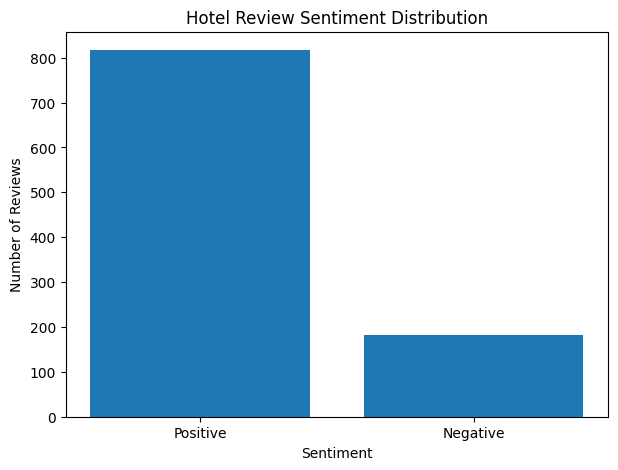

In [17]:
sentiment_count = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(sentiment_count.index,sentiment_count.values)

plt.title("Hotel Review Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

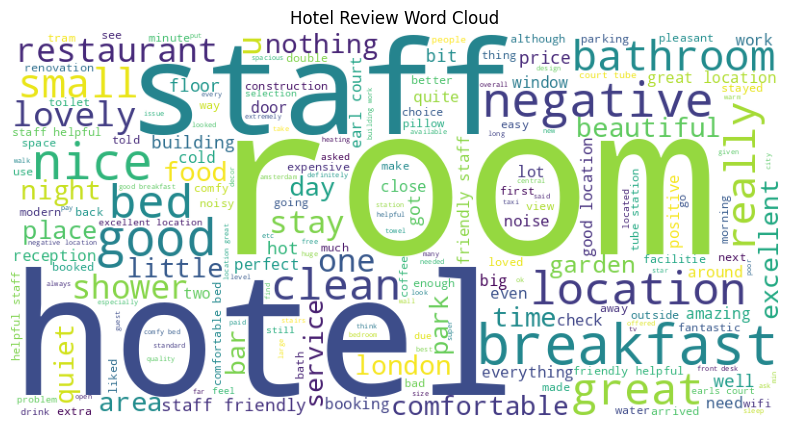

In [18]:
wordcloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Hotel Review Word Cloud")

plt.show()

In [19]:
positive = len(df[df["Sentiment"]=="Positive"])

negative = len(df[df["Sentiment"]=="Negative"])

print("Customer Satisfaction Report")

print("-----------------------------------")

print("Positive Reviews :",positive)

print("Negative Reviews :",negative)

print("\nTop Service Issues")

print(issue_count.most_common(10))

print("\nTop Keywords")

print(word_freq.most_common(10))

print("\nRecommendation")

print("The NLP model successfully analyzes hotel reviews and identifies customer sentiment and service-related issues. The hotel management should improve cleanliness, food quality, room maintenance, and staff service to increase customer satisfaction.")

Customer Satisfaction Report
-----------------------------------
Positive Reviews : 817
Negative Reviews : 183

Top Service Issues
[('staff', 445), ('food', 77), ('noise', 45), ('bad', 32), ('poor', 24), ('smell', 23), ('dirty', 12), ('slow', 10)]

Top Keywords
[('room', 779), ('hotel', 549), ('staff', 476), ('location', 375), ('breakfast', 347), ('good', 314), ('negative', 247), ('great', 243), ('nice', 224), ('bed', 210)]

Recommendation
The NLP model successfully analyzes hotel reviews and identifies customer sentiment and service-related issues. The hotel management should improve cleanliness, food quality, room maintenance, and staff service to increase customer satisfaction.
